---
title: GMST from CESM2 LENS data
author: Harsha R. Hampapura
date: 2026-03-12
---

## Access CESM2 LENS data from NCAR's Geoscience Data Exchange (GDEX) and compute GMST

### Table of Contents
- [Introduction](#Introduction) 
- [Set up Dask Cluster](#Set-up-Dask-Cluster) 
- [Data Loading](#Data-Loading) 
- [Data Analysis](#Data-Analysis)  

## Introduction
- Python package imports and useful function definitions

In [1]:
# Import
import intake
import numpy as np
import xarray as xr
import nc_time_axis
import os

In [2]:
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client
from dask.distributed import performance_report

In [3]:
# Set up your sratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)

/glade/derecho/scratch/harshah


In [4]:
# catalog_url = 'https://osdata.gdex.ucar.edu/d010092/catalogs/d010092-osdf.json' 
catalog_url = 'https://osdata.gdex.ucar.edu/d010092/catalogs/d010092-https.json' #NCAR's Object store

In [5]:
# GMST function ###
# calculate global means
def get_lat_name(ds):
    for lat_name in ['lat', 'latitude']:
        if lat_name in ds.coords:
            return lat_name
    raise RuntimeError("Couldn't find a latitude coordinate")

def global_mean(ds):
    lat = ds[get_lat_name(ds)]
    weight = np.cos(np.deg2rad(lat))
    weight /= weight.mean()
    other_dims = set(ds.dims) - {'time','member_id'}
    return (ds * weight).mean(other_dims)

## Set up Dask Cluster 
- Setting up a dask cluster. You will need an NCAR HPC account to do this.

In [6]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name = 'dask-wk25',
    cores = 1,
    memory = '8GiB',
    processes = 1,
    local_directory = glade_scratch+'/dask/spill/',
    log_directory = glade_scratch + '/dask/logs/',
    resource_spec = 'select=1:ncpus=1:mem=8GB',
    queue = 'casper',
    walltime = '5:00:00',
    interface = 'ext'
)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33005 instead
  warnings.warn(
2026-05-06 16:22:50,905 - distributed.batched - INFO - Batched Comm Closed <TCP (closed)  local=tcp://128.117.208.101:38807 remote=tcp://128.117.208.101:57626>
Traceback (most recent call last):
  File "/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/batched.py", line 115, in _background_send
    nbytes = yield coro
             ^^^^^^^^^^
  File "/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/tornado/gen.py", line 783, in run
    value = future.result()
  File "/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/comm/tcp.py", line 263, in write
    raise CommClosedError()
distributed.comm.core.CommClosedError


In [7]:
# Create the client to load the Dashboard
client = Client(cluster)

In [8]:
n_workers = 5
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

PBSCluster(51471f0f, 'tcp://128.117.208.101:38807', workers=5, threads=5, memory=40.00 GiB)

## Data Loading
- Load CESM2 LENS zarr data from GDEX using an intake-ESM catalog
- For more details regarding the dataset. See, https://gdex.ucar.edu/datasets/d010092/#

In [9]:
# Open collection description file using intake
col   = intake.open_esm_datastore(catalog_url)
col

,unique
,322
variable,54
long_name,52
component,4
experiment,2
forcing_variant,2
frequency,3
vertical_levels,4
spatial_domain,3
units,21


In [10]:
cesm_temp = col.search(variable ='TREFHT', frequency ='monthly')
cesm_temp.df

,,variable,long_name,component,experiment,forcing_variant,frequency,vertical_levels,spatial_domain,units,start_time,end_time,path
0,104,TREFHT,reference height temperature,atm,historical,cmip6,monthly,1.0,global,K,1850-01-16 12:00:00,2014-12-16 12:00:00,https://osdata.gdex.ucar.edu/d010092/atm/month...
1,128,TREFHT,reference height temperature,atm,historical,smbb,monthly,1.0,global,K,1850-01-16 12:00:00,2014-12-16 12:00:00,https://osdata.gdex.ucar.edu/d010092/atm/month...
2,152,TREFHT,reference height temperature,atm,ssp370,cmip6,monthly,1.0,global,K,2015-01-16 12:00:00,2100-12-16 12:00:00,https://osdata.gdex.ucar.edu/d010092/atm/month...
3,176,TREFHT,reference height temperature,atm,ssp370,smbb,monthly,1.0,global,K,2015-01-16 12:00:00,2100-12-16 12:00:00,https://osdata.gdex.ucar.edu/d010092/atm/month...


In [11]:
cesm_temp.df['path'].values

<ArrowExtensionArray>
['https://osdata.gdex.ucar.edu/d010092/atm/monthly/cesm2LE-historical-cmip6-TREFHT.zarr',
  'https://osdata.gdex.ucar.edu/d010092/atm/monthly/cesm2LE-historical-smbb-TREFHT.zarr',
     'https://osdata.gdex.ucar.edu/d010092/atm/monthly/cesm2LE-ssp370-cmip6-TREFHT.zarr',
      'https://osdata.gdex.ucar.edu/d010092/atm/monthly/cesm2LE-ssp370-smbb-TREFHT.zarr']
Length: 4, dtype: large_string[pyarrow]

In [12]:
dsets_cesm = cesm_temp.to_dataset_dict(xarray_open_kwargs={'engine':'zarr','backend_kwargs':{'consolidated': True,'zarr_format': 2}})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.frequency.forcing_variant'


<div><progress max="4" value="4"></progress> 100.00% [4/4 00:23&lt;00:00]</div>

In [13]:
dsets_cesm.keys()

dict_keys(['atm.ssp370.monthly.cmip6', 'atm.historical.monthly.cmip6', 'atm.ssp370.monthly.smbb', 'atm.historical.monthly.smbb'])

In [14]:
historical_cmip6 = dsets_cesm['atm.historical.monthly.cmip6']
future_cmip6     = dsets_cesm['atm.ssp370.monthly.cmip6']

In [15]:
future_cmip6 

<xarray.Dataset> Size: 11GB
Dimensions:    (member_id: 50, time: 1032, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    time_bnds  (time, nbnd) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    TREFHT     (member_id, time, lat, lon) float32 11GB dask.array<chunksize=(1, 600, 192, 288), meta=np.ndarray>
Attributes: (12/23)
    Conventions:                       CF-1.0
    host:                              mom1
    logname:                           sunseon
    model_doi_url:                     https://doi.org/10.5065/D67H1H0V
    source:                            CAM
    time_period_freq:                  month_1
    ...                                ...
    intake_esm_attrs:units:            K
    intake_esm_attrs:start_time:       2015-01-16 12:00:00
    intake_esm_attrs:end_time:         2100-12-16 12:00:00
    intake_esm_attrs:path:             https://osdata.gdex.ucar.edu/d010092/a...
    intake_esm_attrs:_data_format_:    zarr
    intake_esm_dataset_key:            atm.ssp370.monthly.cmip6

### Make a quick plot to check data transfer

CPU times: user 273 ms, sys: 30.9 ms, total: 304 ms
Wall time: 3.74 s


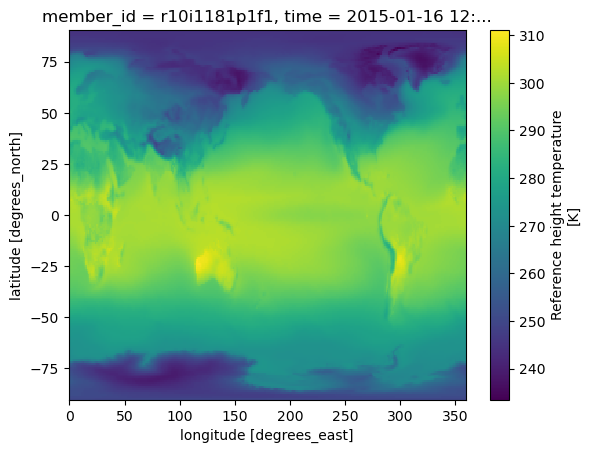

In [16]:
%%time
future_cmip6.TREFHT.isel(member_id=0,time=0).plot()

## Section 4: Data Analysis
- Perform the Global Mean Surface Temperature computation

### Merge datasets and compute Global Mean surrface temperature anomaly
- Warning! This section takes about a min to run!
- Config: 3 dask workers with 8GiB memory.

In [17]:
merge_ds_cmip6 = xr.concat([historical_cmip6, future_cmip6], dim='time')
# merge_ds_cmip6 = merge_ds_cmip6.dropna(dim='member_id')
merge_ds_cmip6 = merge_ds_cmip6.TREFHT
merge_ds_cmip6

<xarray.DataArray 'TREFHT' (member_id: 50, time: 3012, lat: 192, lon: 288)> Size: 33GB
dask.array<concatenate, shape=(50, 3012, 192, 288), dtype=float32, chunksize=(1, 600, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 24kB 1850-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Attributes:
    cell_methods:  time: mean
    long_name:     Reference height temperature
    units:         K

#### Compute (spatially weighted) Global Mean

In [18]:
ds_cmip6_annual = merge_ds_cmip6.resample(time='YS').mean()
ds_cmip6_annual

<xarray.DataArray 'TREFHT' (member_id: 50, time: 251, lat: 192, lon: 288)> Size: 3GB
dask.array<transpose, shape=(50, 251, 192, 288), dtype=float32, chunksize=(1, 50, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 2kB 1850-01-01 00:00:00 ... 2100-01-01 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Attributes:
    cell_methods:  time: mean
    long_name:     Reference height temperature
    units:         K

In [19]:
%%time
gmst_cmip6 = global_mean(ds_cmip6_annual)
gmst_cmip6 = gmst_cmip6.rename('gmst')
gmst_cmip6

CPU times: user 7.82 ms, sys: 0 ns, total: 7.82 ms
Wall time: 73.2 ms


<xarray.DataArray 'gmst' (member_id: 50, time: 251)> Size: 100kB
dask.array<mean_agg-aggregate, shape=(50, 251), dtype=float64, chunksize=(1, 50), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 2kB 1850-01-01 00:00:00 ... 2100-01-01 00:00:00
Attributes:
    cell_methods:  time: mean

### Compute anomaly and plot

In [20]:
gmst_cmip6_ano = gmst_cmip6 - gmst_cmip6.mean()
gmst_cmip6_ano

<xarray.DataArray 'gmst' (member_id: 50, time: 251)> Size: 100kB
dask.array<sub, shape=(50, 251), dtype=float64, chunksize=(1, 50), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 2kB 1850-01-01 00:00:00 ... 2100-01-01 00:00:00
Attributes:
    cell_methods:  time: mean

In [21]:
gmst_cmip6_ano = gmst_cmip6_ano.compute()

CPU times: user 8.85 ms, sys: 0 ns, total: 8.85 ms
Wall time: 8.76 ms


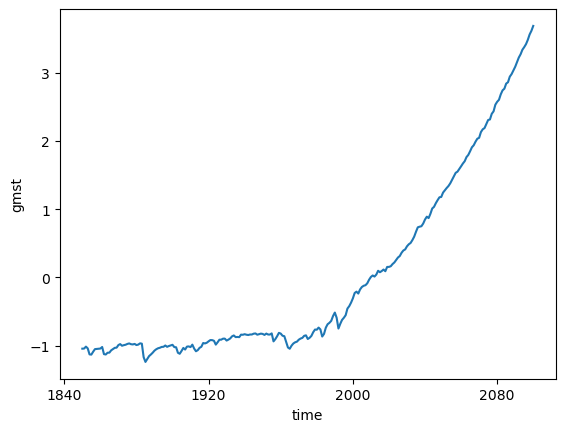

In [22]:
%%time
gmst_cmip6_ano.mean(dim='member_id').plot()

In [23]:
cluster.close()